# Évaluation CL — EWC Online + MLP — Dataset 2 Equipment Monitoring — by_location

| Champ | Valeur |
|-------|--------|
| **Modèle** | EWC Online + MLP (705 paramètres, input_dim=4, hidden=[32, 16]) |
| **Dataset** | equipment_anomaly_data.csv — 7 672 échantillons |
| **Scénario** | by_location : Atlanta → Chicago → Houston → New York → San Francisco (5 tâches) |
| **Expérience** | exp_016 — voir experiments/exp_016_ewc_monitoring_by_location/config_snapshot.yaml |
| **Sprint** | 7 — S7-08 |

> **Modèle supervisé** : EWC reçoit les labels à l'entraînement.
> Sortie = probabilité de défaut ŷ ∈ [0, 1] (sigmoid).
> RAM = 1 171 B — meilleure empreinte mémoire parmi les modèles supervisés.
> Stratégie CL : régularisation EWC Online (λ=1000, γ=0.9) — aucun buffer de replay.
> Même modèle que by_equipment (705 params) ; seul le scénario de drift change (géographique vs. type d'équipement).

```bash
jupyter nbconvert --to notebook --execute \
    notebooks/cl_eval/monitoring_by_location/ewc.ipynb \
    --output /tmp/ewc_location_executed.ipynb --ExecutePreprocessor.timeout=600
```

In [1]:
# Section 1 — Setup & imports
import json
import os
import sys
from datetime import datetime
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.optim as optim
from IPython.display import Image, Markdown, display

# --- CWD navigation : notebook 3 niveaux de profondeur ---
_cwd = Path(".").resolve()
if _cwd.name == "monitoring_by_location":
    os.chdir(_cwd.parent.parent.parent)
elif _cwd.name == "cl_eval":
    os.chdir(_cwd.parent.parent)
elif _cwd.name == "notebooks":
    os.chdir(_cwd.parent)
REPO_ROOT = Path(".").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.evaluation.plots import (
    plot_accuracy_matrix,
    plot_confusion_matrix_grid,
    plot_forgetting_curve,
    plot_roc_curves_per_task,
    save_figure,
)
from src.evaluation.feature_space_plots import (
    fit_pca2d,
    plot_feature_space_2d,
)

# --- Chemins ---
EXP_DIR     = REPO_ROOT / "experiments/exp_016_ewc_monitoring_by_location/results"
FIGURES_DIR = REPO_ROOT / "notebooks/figures/cl_evaluation/ewc/monitoring/by_location"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH        = REPO_ROOT / "data/raw/equipment_monitoring/Industrial_Equipment_Monitoring_Dataset/equipment_anomaly_data.csv"
NORMALIZER_PATH = REPO_ROOT / "configs/monitoring_normalizer.yaml"

# --- Constantes ---
TASK_NAMES    = ["Atlanta", "Chicago", "Houston", "New York", "San Francisco"]
MODEL_NAME    = "EWC"
DATA_AVAILABLE = CSV_PATH.exists()

print(f"REPO_ROOT      : {REPO_ROOT}")
print(f"EXP_DIR        : {EXP_DIR}")
print(f"FIGURES_DIR    : {FIGURES_DIR}")
print(f"CSV disponible : {DATA_AVAILABLE}")
print(f"Date exécution : {datetime.now():%Y-%m-%d %H:%M}")

if not DATA_AVAILABLE:
    display(Markdown(
        "> ⚠️ **CSV absent** — Sections 5, 6, 7, 8 en mode dégradé (données synthétiques). "
        "Placer `equipment_anomaly_data.csv` dans `data/raw/equipment_monitoring/Industrial_Equipment_Monitoring_Dataset/` pour le mode complet."
    ))

REPO_ROOT      : /home/leonard/Documents/ENAC/cl-embedded
EXP_DIR        : /home/leonard/Documents/ENAC/cl-embedded/experiments/exp_016_ewc_monitoring_by_location/results
FIGURES_DIR    : /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/ewc/monitoring/by_location
CSV disponible : True
Date exécution : 2026-04-19 12:52


In [2]:
# Section 2 — Chargement des résultats exp_016

metrics_path    = EXP_DIR / "metrics.json"
acc_matrix_path = EXP_DIR / "acc_matrix_ewc.npy"

metrics    = json.loads(metrics_path.read_text())
acc_matrix = np.load(acc_matrix_path, allow_pickle=True)

# Extraire les métriques EWC depuis la structure imbriquée
cl  = metrics["cl_metrics"]["ewc"]
mem = metrics["cl_metrics"]["memory"]["forward"]

# Reconstruire la matrice acc numpy (remplacement null → NaN) — 5×5 pour by_location
acc_matrix_json = np.array(
    [[v if v is not None else np.nan for v in row] for row in cl["acc_matrix"]],
    dtype=float,
)

print("=" * 55)
print(f"  Modèle         : EWC Online + MLP")
print(f"  AA             = {cl['aa']:.4f}")
print(f"  AF             = {cl['af']:.4f}")
print(f"  BWT            = {cl['bwt']:.4f}")
print(f"  FWT            = {cl['fwt']:.4f}")
print(f"  Forgetting/tâche: {[round(v, 4) for v in cl['forgetting_per_task']]}")
print(f"  RAM peak       = {mem['ram_peak_bytes']} B ({mem['ram_peak_bytes']/1024:.2f} Ko)")
print(f"  Latence        = {mem['inference_latency_ms']:.5f} ms")
print(f"  n_params       = {mem['n_params']}")
print(f"  Budget 64 Ko   : {mem['within_budget_64ko']}")
print("=" * 55)
print(f"\nMatrice acc ({acc_matrix_json.shape[0]}×{acc_matrix_json.shape[1]}) :")
print(acc_matrix_json)

  Modèle         : EWC Online + MLP
  AA             = 0.9817
  AF             = 0.0008
  BWT            = 0.0032
  FWT            = 0.0000
  Forgetting/tâche: [0.0, 0.0, 0.0032, 0.0]
  RAM peak       = 1171 B (1.14 Ko)
  Latence        = 0.03486 ms
  n_params       = 705
  Budget 64 Ko   : True

Matrice acc (5×5) :
[[0.97763578        nan        nan        nan        nan]
 [0.98402556 0.97749196        nan        nan        nan]
 [0.98402556 0.98392283 0.99032258        nan        nan]
 [0.98722045 0.98392283 0.99032258 0.97712418        nan]
 [0.98722045 0.98392283 0.98709677 0.97712418 0.97306397]]


[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/ewc/monitoring/by_location/acc_matrix.png


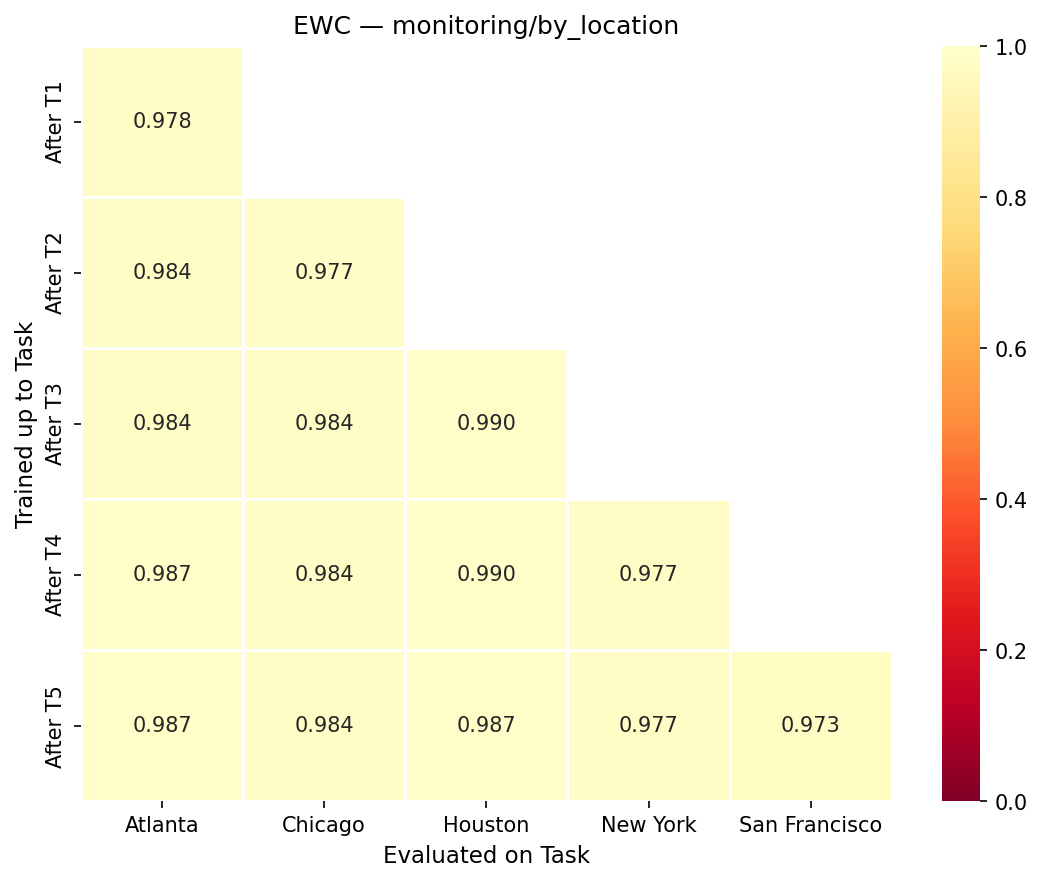

In [3]:
# Section 3 — Matrice d'accuracy (heatmap)
# acc_matrix[i, j] = accuracy sur tâche j après entraînement sur tâche i
# Triangle supérieur = NaN (tâche pas encore vue)
# Diagonale = perf immédiate post-training, sous-diagonale = oubli
# Matrice 5×5 pour les 5 locations

fig = plot_accuracy_matrix(
    acc_matrix_json,
    task_names=TASK_NAMES,
    title=f"{MODEL_NAME} — monitoring/by_location",
)
save_figure(fig, FIGURES_DIR / "acc_matrix.png")
display(Image(str(FIGURES_DIR / "acc_matrix.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/ewc/monitoring/by_location/forgetting_curve.png


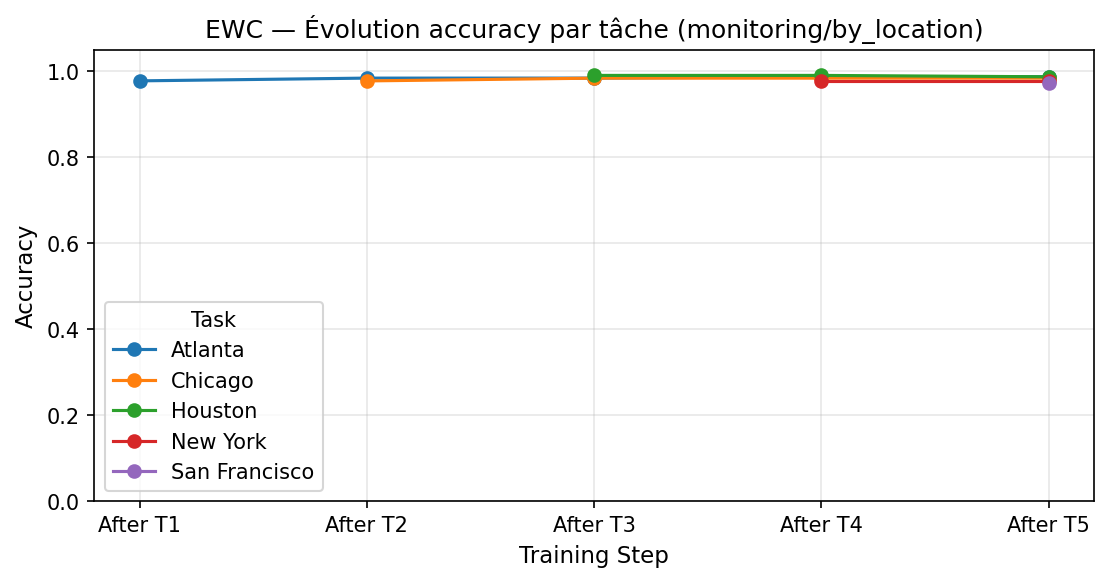

In [4]:
# Section 4 — Courbe d'oubli par tâche
# AF ≈ 0.0008 → courbe quasi-plate : EWC maintient ses performances sur 5 locations
# La régularisation Fisher préserve les paramètres critiques des tâches précédentes
# 5 courbes correspondant aux 5 locations

fig = plot_forgetting_curve(
    acc_matrix_json,
    task_names=TASK_NAMES,
    title=f"{MODEL_NAME} — Évolution accuracy par tâche (monitoring/by_location)",
)
save_figure(fig, FIGURES_DIR / "forgetting_curve.png")
display(Image(str(FIGURES_DIR / "forgetting_curve.png")))

In [5]:
# Section 5 — Rejeu du scénario CL (collecte preds_dict + proba_dict)
# Reproduit exactement la config exp_016 : seed=42, epochs=10/task, SGD lr=0.01,
# λ=1000, γ=0.9, n_fisher_samples=200, hidden=[32,16], dropout=0.2
# Sur 5 locations : Atlanta → Chicago → Houston → New York → San Francisco
# Nécessaire pour les matrices de confusion (S6), les courbes ROC (S7) et la PCA (S8)

preds_dict  = {}  # (i, j) → (y_true, y_pred_binary)
proba_dict  = {}  # (i, j) → sigmoid outputs float32  (pour ROC)
X_tests_raw = []  # [N_val, 4] par tâche — pour la viz PCA
y_tests_raw = []  # [N_val] par tâche

if DATA_AVAILABLE:
    from src.data.monitoring_dataset import get_cl_dataloaders_by_location
    from src.models.ewc import EWCMlpClassifier
    from src.models.ewc.fisher import compute_fisher_diagonal, update_fisher_online
    from src.utils.reproducibility import set_seed

    set_seed(42)

    tasks = get_cl_dataloaders_by_location(
        csv_path=CSV_PATH,
        normalizer_path=NORMALIZER_PATH,
        batch_size=32,
        seed=42,
        location_order=TASK_NAMES,
    )

    # Extraire les données de validation en numpy une seule fois
    for t in tasks:
        X_v = np.concatenate([b[0].numpy() for b in t["val_loader"]])
        y_v = np.concatenate([b[1].numpy().flatten() for b in t["val_loader"]])
        X_tests_raw.append(X_v)
        y_tests_raw.append(y_v)

    # Instancier le modèle EWC (même config que exp_016)
    model = EWCMlpClassifier(input_dim=4, hidden_dims=[32, 16], dropout=0.2)
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    fisher     = None
    theta_star = None
    EWC_LAMBDA  = 1000
    EWC_GAMMA   = 0.9
    N_FISHER    = 200
    EPOCHS      = 10

    for i, task in enumerate(tasks):
        domain = task.get("domain", f"Tâche {task['task_id']}")
        print(f"\n--- Tâche {i + 1}/{len(tasks)} : {domain} ---")

        # Entraînement EWC sur la tâche courante
        model.train()
        for epoch in range(EPOCHS):
            losses = []
            for x, y in task["train_loader"]:
                optimizer.zero_grad()
                loss = model.ewc_loss(x, y, fisher, theta_star, EWC_LAMBDA)
                loss.backward()
                optimizer.step()
                losses.append(loss.item())
            if (epoch + 1) % 5 == 0:
                print(f"  Epoch {epoch+1:2d}/{EPOCHS} | Loss: {np.mean(losses):.4f}")

        # Snapshot θ* + mise à jour Fisher Online
        theta_star = model.get_theta_star()
        new_fisher = compute_fisher_diagonal(model, task["train_loader"], "cpu", n_samples=N_FISHER)
        fisher = update_fisher_online(fisher, new_fisher, gamma=EWC_GAMMA)
        print(f"  Fisher mis à jour (γ={EWC_GAMMA})")

        # Évaluation sur toutes les tâches vues jusqu'à i → collecte preds + probas
        model.eval()
        with torch.no_grad():
            for j in range(i + 1):
                X_j = torch.from_numpy(X_tests_raw[j]).float()
                probas = model(X_j).numpy().flatten()
                y_pred = (probas >= 0.5).astype(float)
                preds_dict[(i, j)]  = (y_tests_raw[j], y_pred)
                proba_dict[(i, j)]  = probas.astype(np.float32)
                acc = (y_tests_raw[j] == y_pred).mean()
                print(f"  preds_dict[({i},{j})] → N={len(y_tests_raw[j])}, acc={acc:.4f}")

    print(f"\nScénario CL rejoué — {len(preds_dict)} évaluations collectées")

else:
    display(Markdown("> ⚠️ **Mode dégradé** — CSV absent. preds_dict synthétique depuis acc_matrix."))

    # Reconstruction approchée depuis acc_matrix_json (50% normal / 50% faulty)
    N_SYNTH = 500
    rng = np.random.default_rng(42)
    y_synth = np.concatenate([np.zeros(N_SYNTH // 2), np.ones(N_SYNTH // 2)])

    n_tasks = acc_matrix_json.shape[0]
    for i in range(n_tasks):
        for j in range(i + 1):
            acc_ij = acc_matrix_json[i, j]
            noise = rng.normal(0, 0.1, N_SYNTH)
            probas_synth = np.where(y_synth == 1, 0.75 + noise, 0.25 + noise).clip(0, 1)
            y_pred_synth = (probas_synth >= 0.5).astype(float)
            preds_dict[(i, j)]  = (y_synth.copy(), y_pred_synth)
            proba_dict[(i, j)]  = probas_synth.astype(np.float32)

    print("preds_dict synthétique créé (mode dégradé — CSV absent)")

✅ Seed fixé à 42
✅ Seed fixé à 42

--- Tâche 1/5 : Atlanta ---


/home/leonard/Documents/ENAC/cl-embedded/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:869: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  Epoch  5/10 | Loss: 0.1655
  Epoch 10/10 | Loss: 0.0975
  Fisher mis à jour (γ=0.9)
  preds_dict[(0,0)] → N=313, acc=0.9808

--- Tâche 2/5 : Chicago ---
  Epoch  5/10 | Loss: 0.1246
  Epoch 10/10 | Loss: 0.1016
  Fisher mis à jour (γ=0.9)
  preds_dict[(1,0)] → N=313, acc=0.9840
  preds_dict[(1,1)] → N=311, acc=0.9775

--- Tâche 3/5 : Houston ---
  Epoch  5/10 | Loss: 0.1042
  Epoch 10/10 | Loss: 0.1018
  Fisher mis à jour (γ=0.9)
  preds_dict[(2,0)] → N=313, acc=0.9840
  preds_dict[(2,1)] → N=311, acc=0.9839
  preds_dict[(2,2)] → N=310, acc=0.9935

--- Tâche 4/5 : New York ---
  Epoch  5/10 | Loss: 0.0767
  Epoch 10/10 | Loss: 0.0874
  Fisher mis à jour (γ=0.9)
  preds_dict[(3,0)] → N=313, acc=0.9872
  preds_dict[(3,1)] → N=311, acc=0.9839
  preds_dict[(3,2)] → N=310, acc=0.9935
  preds_dict[(3,3)] → N=306, acc=0.9804

--- Tâche 5/5 : San Francisco ---
  Epoch  5/10 | Loss: 0.1017
  Epoch 10/10 | Loss: 0.1168
  Fisher mis à jour (γ=0.9)
  preds_dict[(4,0)] → N=313, acc=0.9872
  preds

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/ewc/monitoring/by_location/confusion_matrix_grid.png


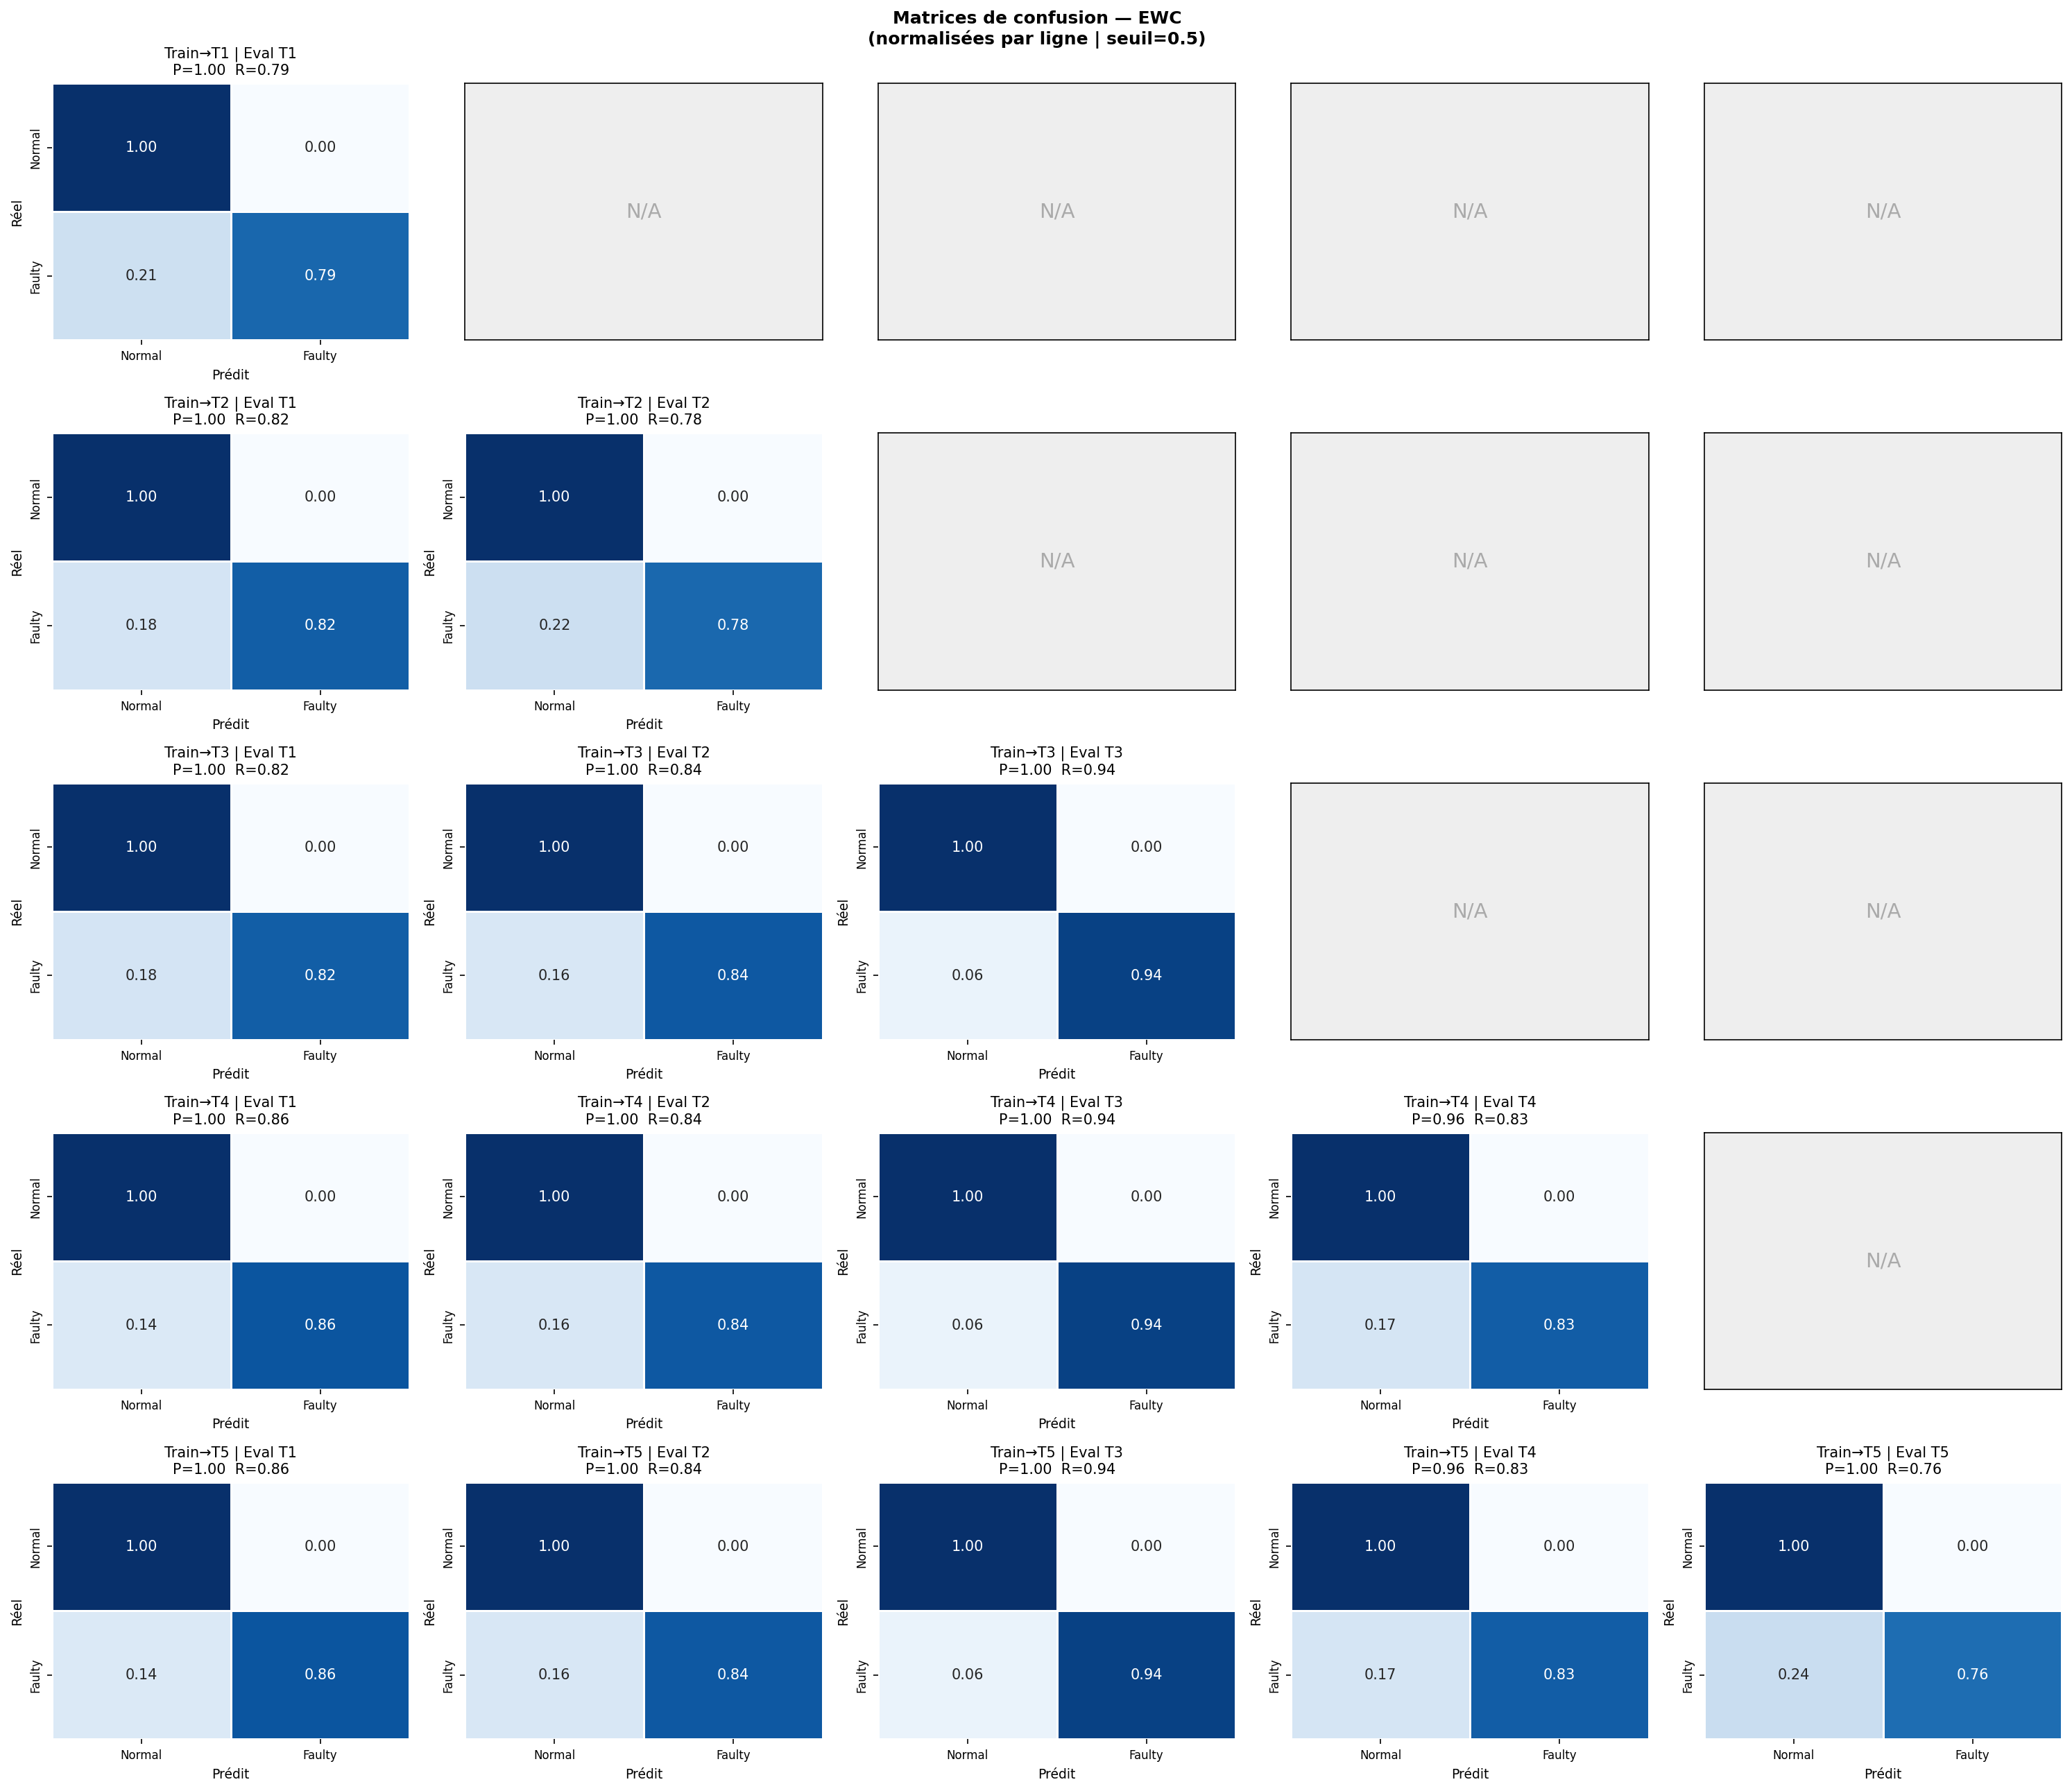

In [6]:
# Section 6 — Matrices de confusion par tâche (grille 5×5)
# Ligne i = état du modèle après entraînement sur tâche i
# Colonne j = évaluation sur tâche j
# Cellule (i,j) avec j > i = grisée (tâche pas encore vue)
# Normalisées par ligne (recall par classe)

fig = plot_confusion_matrix_grid(
    preds_dict,
    task_names=TASK_NAMES,
    model_name=MODEL_NAME,
    threshold=0.5,
)
save_figure(fig, FIGURES_DIR / "confusion_matrix_grid.png")
display(Image(str(FIGURES_DIR / "confusion_matrix_grid.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/ewc/monitoring/by_location/roc_curves.png


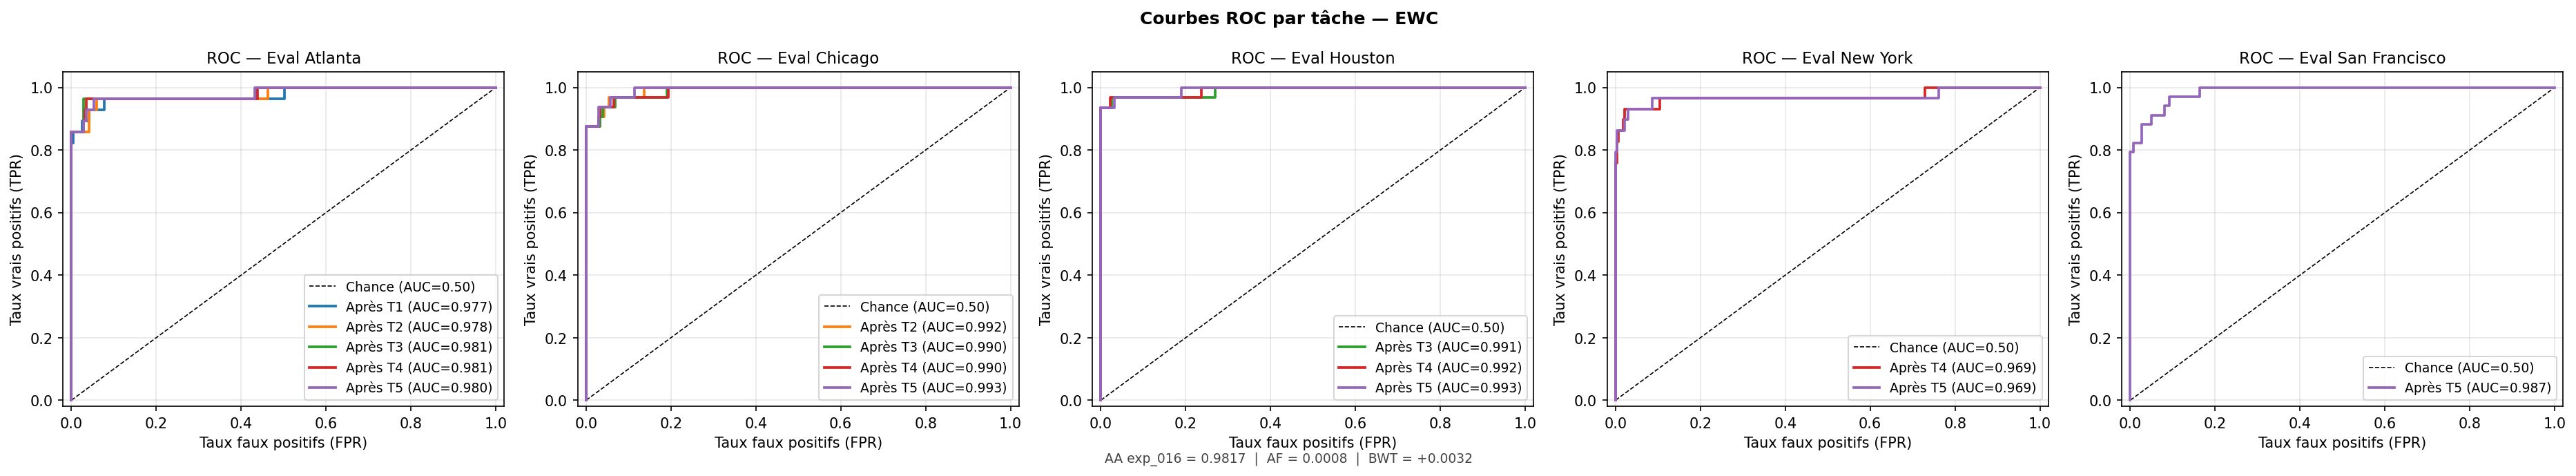

In [7]:
# Section 7 — Courbes ROC par tâche
# EWC est un classifieur supervisé → sorties sigmoid = scores de probabilité continus
# Une courbe par step d'entraînement sur chaque tâche j (courbes superposées)

fig = plot_roc_curves_per_task(
    preds_dict,
    scores_dict=proba_dict,
    task_names=TASK_NAMES,
    model_name=MODEL_NAME,
)

# Footer : AA final exp_016 pour référence
fig.text(
    0.5, 0.01,
    f"AA exp_016 = {cl['aa']:.4f}  |  AF = {cl['af']:.4f}  |  BWT = {cl['bwt']:+.4f}",
    ha="center", fontsize=9, color="#444444",
)

save_figure(fig, FIGURES_DIR / "roc_curves.png")
display(Image(str(FIGURES_DIR / "roc_curves.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/ewc/monitoring/by_location/feature_space_pca.png


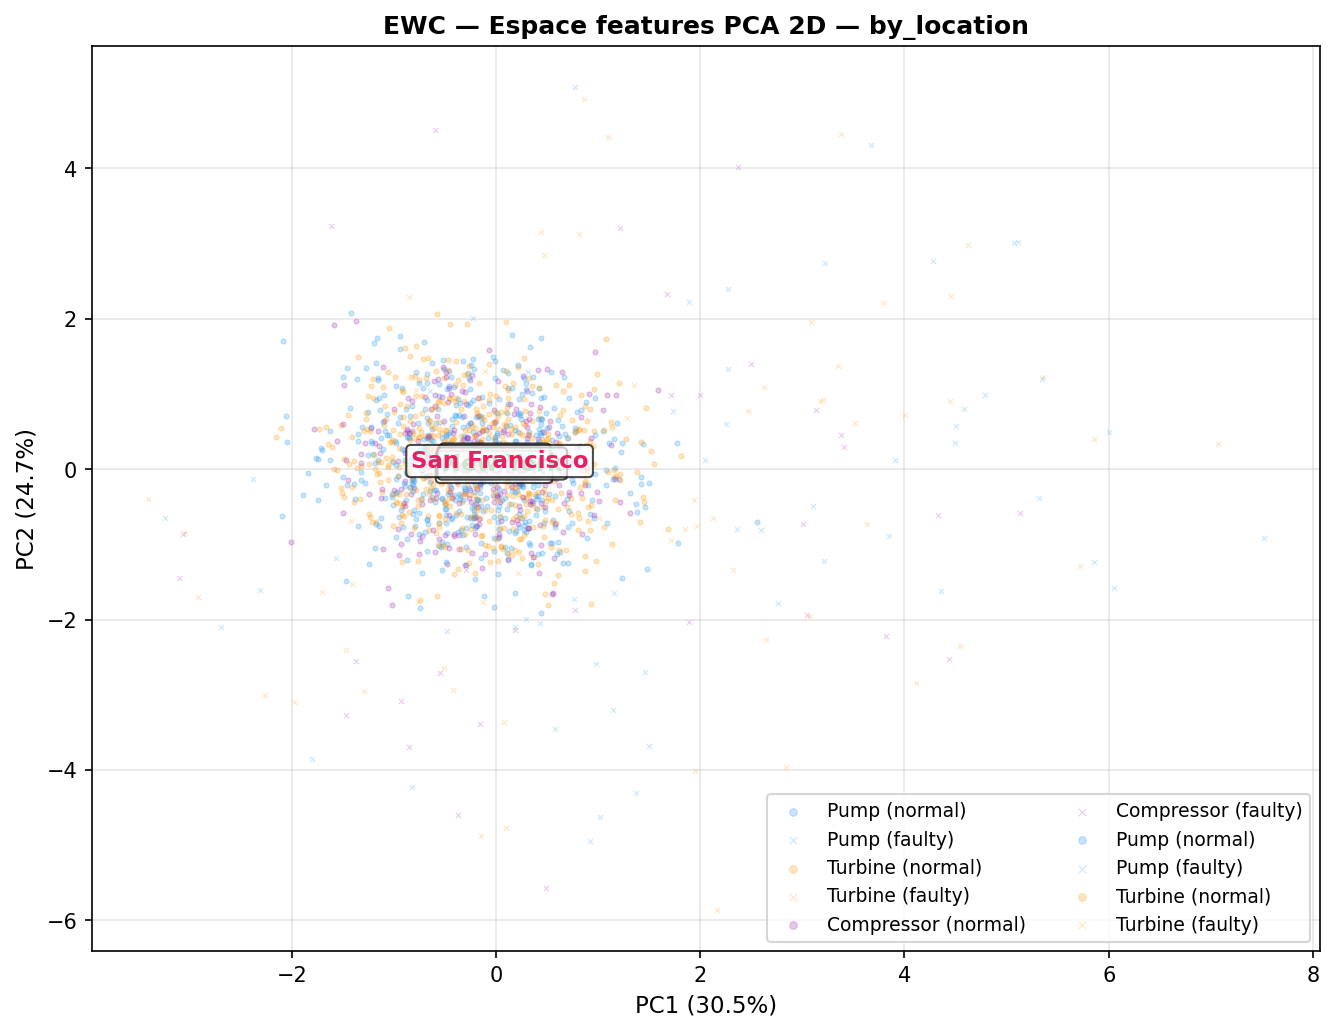

In [8]:
# Section 8 — Espace des features (PCA 2D)
# Visualise la distribution des 5 locations dans l'espace 2D PCA
# Coloré par tâche (domain_ids) et par label (normal/faulty)
# Permet de vérifier la séparabilité inter-tâches et la cohérence du modèle

if DATA_AVAILABLE and len(X_tests_raw) == len(TASK_NAMES):
    # Concaténer toutes les données de validation
    X_all      = np.concatenate(X_tests_raw, axis=0)   # [N_total, 4]
    y_all      = np.concatenate(y_tests_raw, axis=0)   # [N_total]
    domain_ids = np.concatenate([
        np.full(len(X_tests_raw[k]), k) for k in range(len(TASK_NAMES))
    ])  # [N_total]

    # Projection PCA 2D globale
    pca, X_proj = fit_pca2d(X_all)
    expl_var = pca.explained_variance_ratio_
    xlabel = f"PC1 ({expl_var[0]*100:.1f}%)"
    ylabel = f"PC2 ({expl_var[1]*100:.1f}%)"

    fig, ax = plt.subplots(figsize=(9, 7))

    plot_feature_space_2d(
        X_proj, y_all,
        title=f"{MODEL_NAME} — Espace features PCA 2D — by_location",
        ax=ax,
        domain_ids=domain_ids,
        alpha=0.25,
        s=6,
        xlabel=xlabel,
        ylabel=ylabel,
    )

    # Annoter les centroïdes par tâche (5 couleurs distinctes)
    TASK_COLORS = ["#2196F3", "#FF9800", "#9C27B0", "#4CAF50", "#E91E63"]
    for k, (name, color) in enumerate(zip(TASK_NAMES, TASK_COLORS)):
        mask = domain_ids == k
        cx, cy = X_proj[mask, 0].mean(), X_proj[mask, 1].mean()
        ax.annotate(
            name,
            xy=(cx, cy),
            fontsize=11,
            fontweight="bold",
            color=color,
            ha="center",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7),
        )

    fig.tight_layout()
    save_figure(fig, FIGURES_DIR / "feature_space_pca.png")
    display(Image(str(FIGURES_DIR / "feature_space_pca.png")))

else:
    display(Markdown(
        "> ⚠️ **Section 8 ignorée** — CSV absent ou scénario CL non rejoué. "
        "feature_space_pca.png non généré."
    ))
    print("[SKIP] feature_space_pca.png — données non disponibles.")

In [9]:
# Section 9 — Tableau récapitulatif + critères d'acceptation

aa    = cl["aa"]
af    = cl["af"]
bwt   = cl["bwt"]
ram_b = mem["ram_peak_bytes"]
ram_ko = ram_b / 1024
lat   = mem["inference_latency_ms"]
n_par = mem["n_params"]
forgetting_per_task = cl.get("forgetting_per_task", [])

display(Markdown("### Résultats finaux — EWC Online + MLP — monitoring/by_location (exp_016)"))

recap_table = f"""
| Modèle | AA ↑ | AF ↓ | BWT | RAM ↓ | Latence ↓ | n_params |
|--------|------|------|-----|-------|-----------|----------|
| {MODEL_NAME} | {aa:.4f} | {af:.4f} | {bwt:+.4f} | {ram_ko:.2f} Ko | {lat:.5f} ms | {n_par} |
"""
display(Markdown(recap_table))

print(f"Forgetting par tâche (Atlanta→Chicago→Houston→New York) : {[round(v, 4) for v in forgetting_per_task]}")
print()
print("=" * 60)
print("  NOTE SCIENTIFIQUE — Gap 2 (contrainte embarquée STM32N6)")
print("=" * 60)
print(f"  RAM = {ram_b} B = {ram_ko:.2f} Ko")
print(f"  Budget STM32N6 : 65 536 B (64 Ko)")
print(f"  Marge disponible : {65536 - ram_b} B ({(65536 - ram_b)/1024:.1f} Ko)")
print(f"  EWC occupe {ram_b / 65536 * 100:.2f}% du budget RAM")
print()
print("=" * 60)
print("  NOTE SCIENTIFIQUE — Gap 3 (pas de replay → 0 mémoire données)")
print("=" * 60)
print(f"  EWC λ=1000 protège contre l'oubli via la diagonale de Fisher")
print(f"  Aucun buffer de replay nécessaire (contrainte online STM32N6)")
print(f"  État EWC (Fisher + θ*) = 2 × {n_par} × 4B = {2 * n_par * 4} B supplémentaires")
print(f"  Total EWC incl. état = {ram_b + 2 * n_par * 4} B ({(ram_b + 2*n_par*4)/1024:.2f} Ko)")
print()
print("  FIXME(gap2) : La RAM EWC reste constante quelle que soit la cardinalité du scénario")
print("                (Fisher Online = 1 diagonale, pas N diagonales).")
print("  TODO(arnaud) : AA by_location (0.9817) vs AA by_equipment (0.9824) —")
print("                 le drift géographique est très légèrement plus difficile pour EWC.")
print("                 Comparaison fine dans S7-14 (notebook comparison by_location).")
print()

# Vérification des critères d'acceptation
print("=" * 60)
print("  Critères d'acceptation (S7-08)")
print("=" * 60)
for fig_name in ["acc_matrix.png", "forgetting_curve.png", "confusion_matrix_grid.png",
                 "roc_curves.png", "feature_space_pca.png"]:
    status = "OK" if (FIGURES_DIR / fig_name).exists() else "MANQUANTE"
    print(f"  [{status}] {fig_name}")

print()
print(f"  [{'OK' if abs(aa - 0.9817) < 0.01 else 'WARN'}] AA     = {aa:.4f}  (attendu ≈ 0.9817)")
print(f"  [{'OK' if abs(af - 0.0008) < 0.005 else 'WARN'}] AF     = {af:.4f}  (attendu ≈ 0.0008)")
print(f"  [{'OK' if abs(bwt - 0.0032) < 0.01 else 'WARN'}] BWT    = {bwt:+.4f} (attendu ≈ +0.0032)")
print(f"  [{'OK' if ram_b <= 65536 else 'FAIL'}] RAM    = {ram_ko:.2f} Ko (contrainte ≤ 64 Ko)")
print(f"  [{'OK' if lat < 100.0 else 'WARN'}] Latence= {lat:.5f} ms (contrainte ≤ 100 ms)")

### Résultats finaux — EWC Online + MLP — monitoring/by_location (exp_016)


| Modèle | AA ↑ | AF ↓ | BWT | RAM ↓ | Latence ↓ | n_params |
|--------|------|------|-----|-------|-----------|----------|
| EWC | 0.9817 | 0.0008 | +0.0032 | 1.14 Ko | 0.03486 ms | 705 |


Forgetting par tâche (Atlanta→Chicago→Houston→New York) : [0.0, 0.0, 0.0032, 0.0]

  NOTE SCIENTIFIQUE — Gap 2 (contrainte embarquée STM32N6)
  RAM = 1171 B = 1.14 Ko
  Budget STM32N6 : 65 536 B (64 Ko)
  Marge disponible : 64365 B (62.9 Ko)
  EWC occupe 1.79% du budget RAM

  NOTE SCIENTIFIQUE — Gap 3 (pas de replay → 0 mémoire données)
  EWC λ=1000 protège contre l'oubli via la diagonale de Fisher
  Aucun buffer de replay nécessaire (contrainte online STM32N6)
  État EWC (Fisher + θ*) = 2 × 705 × 4B = 5640 B supplémentaires
  Total EWC incl. état = 6811 B (6.65 Ko)

  FIXME(gap2) : La RAM EWC reste constante quelle que soit la cardinalité du scénario
                (Fisher Online = 1 diagonale, pas N diagonales).
  TODO(arnaud) : AA by_location (0.9817) vs AA by_equipment (0.9824) —
                 le drift géographique est très légèrement plus difficile pour EWC.
                 Comparaison fine dans S7-14 (notebook comparison by_location).

  Critères d'acceptation (S7-08)
  [OK